<a href="https://colab.research.google.com/github/raghavjoshi03/Machine-Learning/blob/tensorFlow/01_neural_network_regression_with_tensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to regression with Neural Networks in TensorFlow

There are many definitions for regression problem but in our case, we are going to simplify it: Predicting a numerical variable based on some other combinations of variables, even shorter... predicting a number.

In [149]:
# Import tensorflow
import tensorflow as tf
print(tf.__version__)

2.20.0


# Creating some data to view and fit

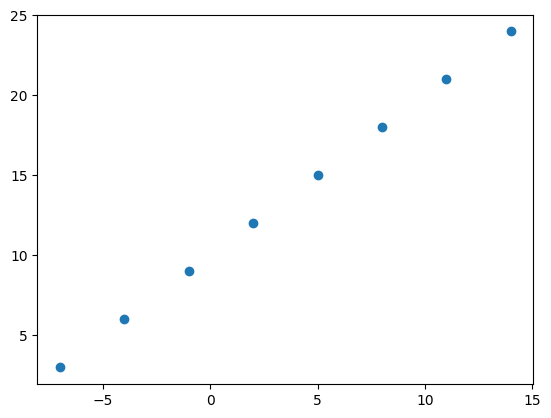

In [150]:
import numpy as np
import matplotlib.pyplot as plt

# Create the features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Vizualize it
plt.scatter(X, y)

In [151]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and Output Shapes

In [152]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [153]:
X[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [154]:
X[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [155]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [156]:
X[0].ndim

0

In [157]:
# Turn our Numpy arrays into tensors (and ensure float32 dtype)
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.expand_dims(tf.constant(y), axis=-1), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [158]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([1]))

### Steps in modelling with tensorFlow

1. **Creating a model**- Define the input and output layers as well as the hidden layers of a deep learning model.

2. **Compiling the model**- Defining the loss function(In other words, in other words the function which tells our model how wrong it is) and the optimizer(tells our model how to improve patterns it's learning) and evalutaion metrics(what we can use to interpret the performance of our model).

3. **Fitting the Model**- Letting the model try to find patterns between X & y (Features and Labels).  

1. Construct or import a pretrained model relevent to your problem

2. Compile the model(prepare it to be used with the data)
* Loss- How wrong your model's predictions are compared to the truth tables.

* Optimizers- How your model should update it's internal patterns to better it's predictions.

* Metrics- Human interpretable values for how well your model is doing.

3. Fit the model to the training data so that it can discover patterns.

* Epochs- How many times the model will go through all of the training examples.

4. Evaluate the model on test data(how reliable are our model's predictions)

In [159]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model using Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Added input_shape argument
])

# 2. Compile the model
model.compile(loss = tf.keras.losses.mae, #mae is the short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"]
              )

# Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step - loss: 10.6956 - mae: 10.6956
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 10.5631 - mae: 10.5631
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 10.4306 - mae: 10.4306
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 10.2981 - mae: 10.2981
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 10.1656 - mae: 10.1656


In [160]:
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [161]:
y_pred = model.predict(tf.constant([[17.0]], dtype=tf.float32))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


array([[16.646408]], dtype=float32)

In [162]:
y_pred+11

array([[27.646408]], dtype=float32)

### Improving the model

We can improve our model by improving the steps we took to create a model.

1. ** Creating a Model** - here we might add more layers, increase the number of hidden units(all called neurons) within each of the hidden layers, change the activation functions of each layer.

2. **Compiling the Model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.

3. **Fitting the model**- here we might fit a model for more **epochs**(leave it training for longer) or on more data (give the model more exmples to learn from).

In [163]:
# Lets rebuild the model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Re-added input_shape argument
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# Fit the model
model.fit(X, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - loss: 8.4201 - mae: 8.4201
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 8.2876 - mae: 8.2876
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 8.1551 - mae: 8.1551
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 8.0226 - mae: 8.0226
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 7.8901 - mae: 7.8901
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 7.7576 - mae: 7.7576
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 7.6251 - mae: 7.6251
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 7.4926 - mae: 7.4926
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 7.4400 - mae: 7.4400
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 7.4344 - mae: 7.4344
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 7.4288 - mae: 7.4288
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 7.4231 - mae: 7.4231
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [164]:
# Remind ourselves of the data
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

In [165]:
# Let's see if our model's prediction has improved
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[30.20381]], dtype=float32)

In [166]:
tf.random.set_seed(42)

# Create the model with a single Dense layer for a linear relationship
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape = [1]) # Single neuron for linear output
], name="linear_model") # Give it a descriptive name

# Compile the model
model.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ["mae"]
)

# Fit the model on the TRAINING data
model.fit(X, y, epochs=100, verbose=0) # Train on X_train, y_train

In [167]:
# let's remind ourselves of the data
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[ 3.],
        [ 6.],
        [ 9.],
        [12.],
        [15.],
        [18.],
        [21.],
        [24.]], dtype=float32)>)

### Even though our loss and MAE are lower, what it might be doing is overfitting ie. it's learning the training data too well, so it's learning the patterns between X and y far too well so when it sees

In [168]:
# Let's try to make a prediction
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[16.154234]], dtype=float32)

### Ways to improve the model

1. Adding Layers
2. Inrease the number of hidden units
3. Change the activation Function.
4. Change the optimization functions.
5. Change the learning rate
6. Fitting on more data
7. Fitting for longer.

## Evaluating a model's performance

In practice, a typical workflow you will go through when building a neural network is:

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...
```

When it comes to evaluation there are 3 words you should memorize:

>    "Visualize, Visualize, Visualize"

It's a good idea to visualize:
* What data are we working with? What does it look like?
* The model itself- What does our model look like?
* The training of our model- How does a model perform while it learns.
* The predictions of a model- How do the predictions of a model line up against the ground truth(the orignal labels).

In [169]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [170]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

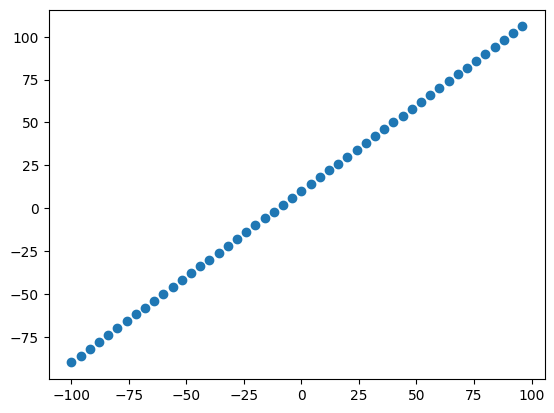

In [171]:
# Visualize the data
import matplotlib.pyplot as plt
plt.scatter(X, y)

### The 3 sets

* **training set**- the model learns from this data which is typically which is typically 70-80% of the total data available.

* **Validation set**- The model gets tuned on this data, which is typically 10-15% of the data available.

* **Test set**- The model gets evaluated on this data to test what it has learned, this set is typiclly 10-15% of the data available.

In [172]:
# check the length of how many samples we have
len(X)

50

In [173]:
# Split the data into train and test sets
X_train = X[:40]
X_test = X[40:]

y_train = y[:40]
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we have got our data in training and testing sets... visualize it again.

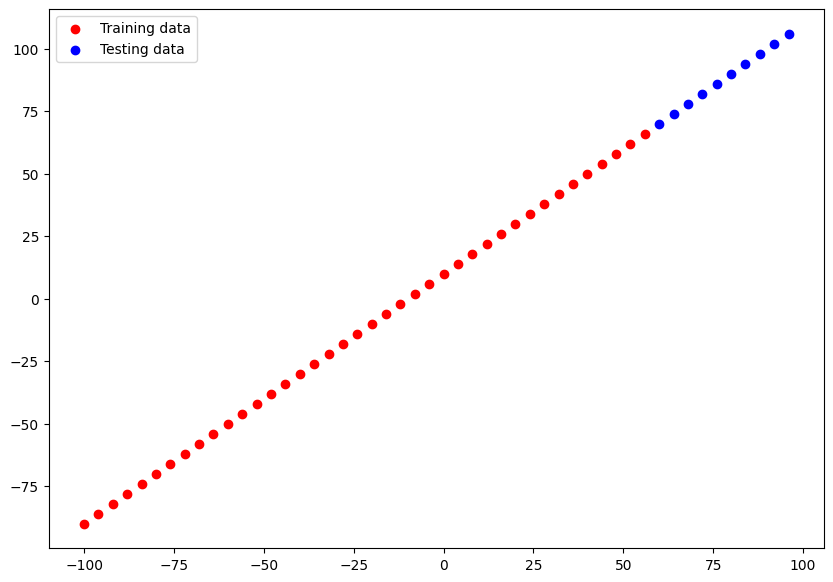

In [174]:
plt.figure(figsize=(10, 7))
# Plot the training data in blue
plt.scatter(X_train, y_train, c="r", label="Training data")
# Plot the testing data in blue
plt.scatter(X_test, y_test, c="b", label="Testing data")
# Show a legend
plt.legend();

In [175]:
# Let's have a look at how to build a Neural Network for our data

# 1. Create a model
model= tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

In [176]:
# Visualizing the model
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [177]:
tf.random.set_seed(42)

# Create a simpler model with a single Dense layer for a linear relationship
model = tf.keras.Sequential([
    tf.keras.Input(shape=[1]), # Define input shape explicitly with Input layer
    tf.keras.layers.Dense(1) # Single neuron for linear output
], name="simple_linear_model") # Give it a descriptive name

# Compile the model
model.compile(loss = tf.keras.losses.mae, #mae is the short for mean absolute error
              optimizer = tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 101.7361 - mae: 101.7361 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 66.9606 - mae: 66.9606
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 32.4349 - mae: 32.4349
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.6830 - mae: 7.6830
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.1773 - mae: 10.1773
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 11.7533 - mae: 11.7533
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.5802 - mae: 12.5802
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.3996 - mae: 8.3996
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 9.0714 - mae: 9.0714
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.9073 - mae: 7.9073
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 10.8475 - mae: 10.8475
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.6591 - mae: 7.6591
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

In [178]:
model.summary()

Model: "simple_linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* total params-Total number of parameters in the model.
* trainable parameters- these are the parameters that the model can update(train) as it trains.
* Non trainable pramaters- these parameters aren't updated duraing training (this is typical when you bring in already learn patternsor parametersfrom other models during **transfer learning**).

⛏ **Exercise**- Try playing around with the number of hidden units in a Dense layer, see how that effets the number of parameters(total and trainable) by calling the model.summary().

📚 **Resources**: For more in-depth overview of the trainable parameters within a layer, check out MIT's introduction to deep learning video.

In [179]:
# Let's fit our model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0)

In [180]:
# Get a summary of our model
model.summary()

Model: "simple_linear_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

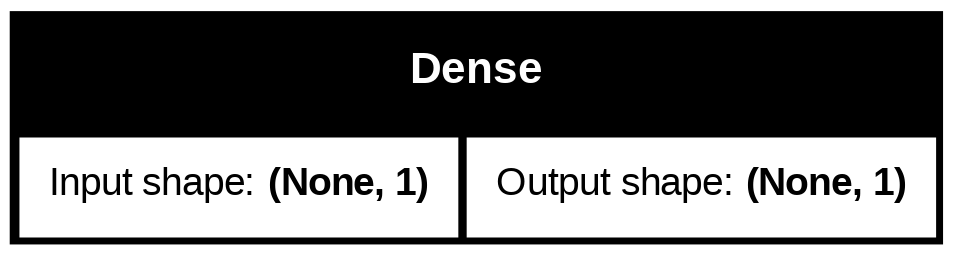

In [181]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Visualizing our model's Prediction

To visualize predictions it's good idea to plotbthem against the grund truth labels.

Often you will see this in the form `y_test` or `y_true` versus `y_pred`(ground truth versus your model's predictions)

In [182]:
# Make so predictions
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[ 71.254845],
       [ 75.82384 ],
       [ 80.39283 ],
       [ 84.961815],
       [ 89.53081 ],
       [ 94.09979 ],
       [ 98.668785],
       [103.23778 ],
       [107.80676 ],
       [112.375755]], dtype=float32)

Now, let's evaluate the model on the test set using the Mean Absolute Error (MAE) metric, which was defined during model compilation.

In [183]:
# Evaluate the model on the test data
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 3.8153 - mae: 3.8153


[3.815300703048706, 3.815300703048706]

Finally, let's visualize these predictions against the true test labels.

In [184]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

🔑 **Note**- If you are going to use some kind of functionality in the future it is a good idea to turn it into a function.

In [185]:
# Let's create a plotting function

def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = y_pred
                     ):
  """Plots the training data, testing data and compares the predictions to the ground truth labels"""
  plt.figure(figsize=(10, 7))

  #plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training Data")
  # plot testing data in Green
  plt.scatter(test_data, test_labels, c="g", label="Testing Data")
  # plot model's prediction in red
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();
  plt.show() # Added to ensure the plot is displayed

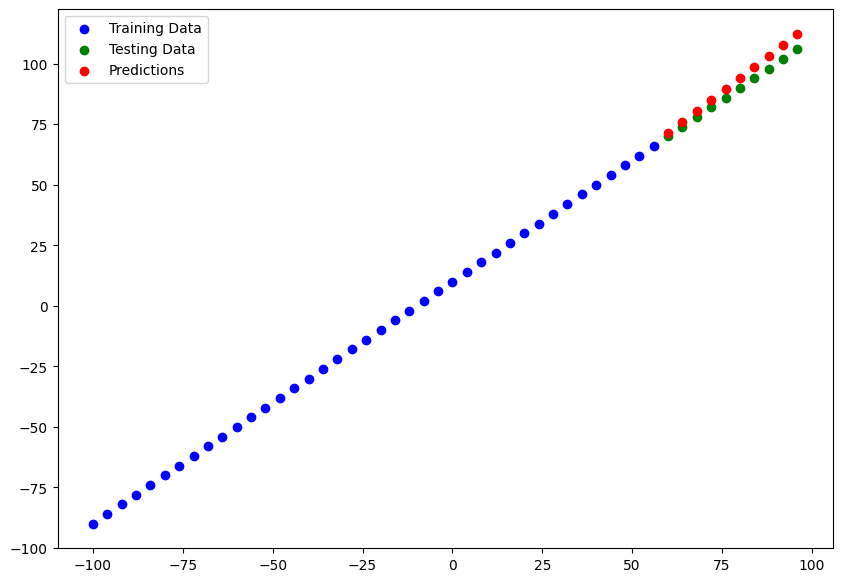

In [186]:
plot_predictions(train_data = X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_pred)

### Evaluating our model's predictions with regression evaluation metrics.

Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.

Since we are working on a regression problem, two of the main metrics:

* MAE - Mean Absolute Error, "on average, how wrong is each of my model's predictions"

* MSE- Mean Square Error, "square the average errors"



In [187]:
# Evaluate the model on test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.8153 - mae: 3.8153


[3.815300703048706, 3.815300703048706]

In [188]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 71.254845],
       [ 75.82384 ],
       [ 80.39283 ],
       [ 84.961815],
       [ 89.53081 ],
       [ 94.09979 ],
       [ 98.668785],
       [103.23778 ],
       [107.80676 ],
       [112.375755]], dtype=float32)>

In [189]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [190]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 71.254845,  75.82384 ,  80.39283 ,  84.961815,  89.53081 ,
        94.09979 ,  98.668785, 103.23778 , 107.80676 , 112.375755],
      dtype=float32)>

In [191]:
# Calculate the mean absolute error
mae = tf.metrics.MAE(y_true=y_test, y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=3.815300703048706>

In [192]:
# Calculate the mean Square error
mse = tf.metrics.MSE(y_true=y_test, y_pred=tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=17.22745132446289>

In [193]:
# Let's use some functions to reuse the MSE and MAE
def mae(y_true, y_pred):
  return tf.metrics.MAE(y_true=y_true, y_pred=y_pred)

def mse(y_true, y_pred):
  return tf.metrics.MSE(y_true=y_true, y_pred=y_pred)

### Running experiments to improve our model

```
Build a model-> fit it -> evaluate it -> tweak it -> fit it -> evaluate it -> tweak it-> fit it -> evaluate it....
```

1. Get more data - get more examples for your model to train on(more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger(using a more complex model) -this might come in form of layers or more hidden units in each layers.
3. Train for longer- give your model more of a chance to find patterns in the data.

Let's do 3 modelling experiments:
1. `model_1`-Same as  the orignal model, 1 layer, trained for 100 epochs.

2. `model_2`- 2 layers trained for 100 epochs.

3. `model_3`- 2 layers trained for 500 epochs.


**Build model_1**

In [194]:
X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [195]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Add input_shape to specify input dimensions
])

# Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])

# Fit the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 20.7447 - mae: 20.7447 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.1953 - mae: 10.1953
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 11.7857 - mae: 11.7857
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 12.5474 - mae: 12.5474
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.3884 - mae: 8.3884
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.9011 - mae: 8.9011
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.7897 - mae: 8.7897
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.5242 - mae: 8.5242
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.2796 - mae: 9.2796
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.3719 - mae: 8.3719
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.0577 - mae: 9.0577
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 7.8642 - mae: 7.8642
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


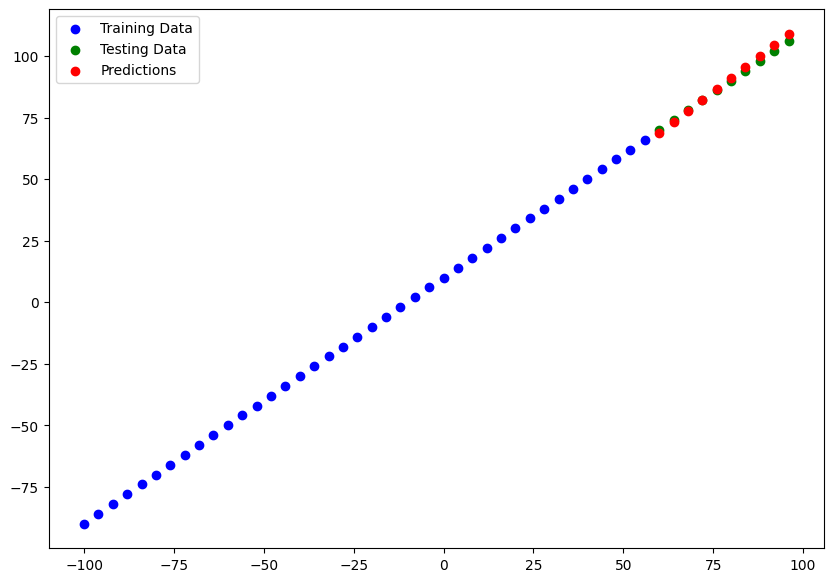

In [196]:
# Make and plot predictions for model
y_pred = model.predict(X_test)
plot_predictions(predictions=y_pred)

In [197]:
tf.constant(y_pred), tf.squeeze(y_pred)

(<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
 array([[ 68.67023 ],
        [ 73.15433 ],
        [ 77.63843 ],
        [ 82.12253 ],
        [ 86.60662 ],
        [ 91.09072 ],
        [ 95.57482 ],
        [100.058914],
        [104.543015],
        [109.027115]], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([ 68.67023 ,  73.15433 ,  77.63843 ,  82.12253 ,  86.60662 ,
         91.09072 ,  95.57482 , 100.058914, 104.543015, 109.027115],
       dtype=float32)>)

In [198]:
# Calculate model evaluation metrics
mae1 = mae(y_test, tf.squeeze(y_pred))
mse1 = mse(y_test, tf.squeeze(y_pred))
mae1, mse1

(<tf.Tensor: shape=(), dtype=float32, numpy=1.3560752868652344>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.6536402702331543>)

**Build `model_2`**

* 2 Dense layers for 100 epochs

In [199]:
# Set random seed
tf.random.set_seed(42)

# Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# Compiling the model
model_2.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), # Changed optimizer to Adam
                metrics = ["mse"])

# Fit the model
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 31.2697 - mse: 1320.3044 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 25.5778 - mse: 879.0106
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 19.9889 - mse: 532.1138
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 14.5032 - mse: 283.0058
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.5974 - mse: 133.2039
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.2708 - mse: 84.3652
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 10.1455 - mse: 103.2948
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.9893 - mse: 125.6622
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.0474 - mse: 128.4260
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 10.5129 - mse: 113.1918
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9.5370 - mse: 91.2797 
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.2374 - mse: 76.0723
Epoch 13/100
2/2 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


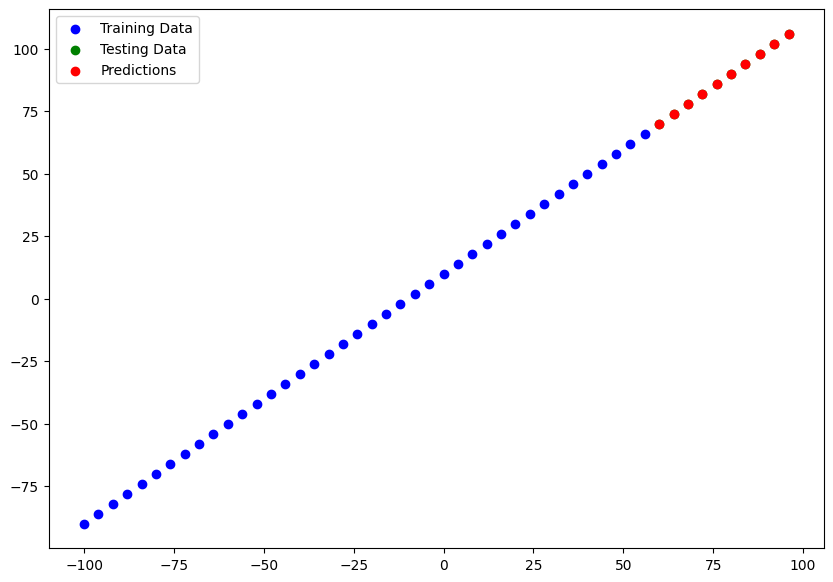

In [200]:
# Make and plot predictions of model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [201]:
# Calculate model_2 evaluation metrics
mae_2 = mae(y_test, tf.squeeze(y_preds_2))
mse_2 = mse(y_test, tf.squeeze(y_preds_2))
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=0.06930847465991974>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.00480492040514946>)

In [202]:
mae2 = mae(y_test, tf.squeeze(y_preds_2))
mse2 = mse(y_test, tf.squeeze(y_preds_2))
mae2, mse2

(<tf.Tensor: shape=(), dtype=float32, numpy=0.06930847465991974>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.00480492040514946>)

**Build `model_3`**

* 2 layers, trained for 500 epochs

In [203]:
# Set the random seed
tf.random.set_seed(42)

# Create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01), # Set learning rate to 0.01
                metrics = ["mse"])

# Fit the model (correctly train model_3)
model_3.fit(X_train, y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 24.8885 - mse: 832.2482 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 19.2124 - mse: 491.2267
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 13.5429 - mse: 248.4514
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.7889 - mse: 112.0299
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.9529 - mse: 86.0344
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.5793 - mse: 114.0389
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 11.0456 - mse: 128.7532
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.6693 - mse: 118.0574
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.6830 - mse: 94.0905
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.2589 - mse: 75.4532
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.2584 - mse: 79.0441
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.2445 - mse: 98.4443
Epoch 13/500
2/2 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


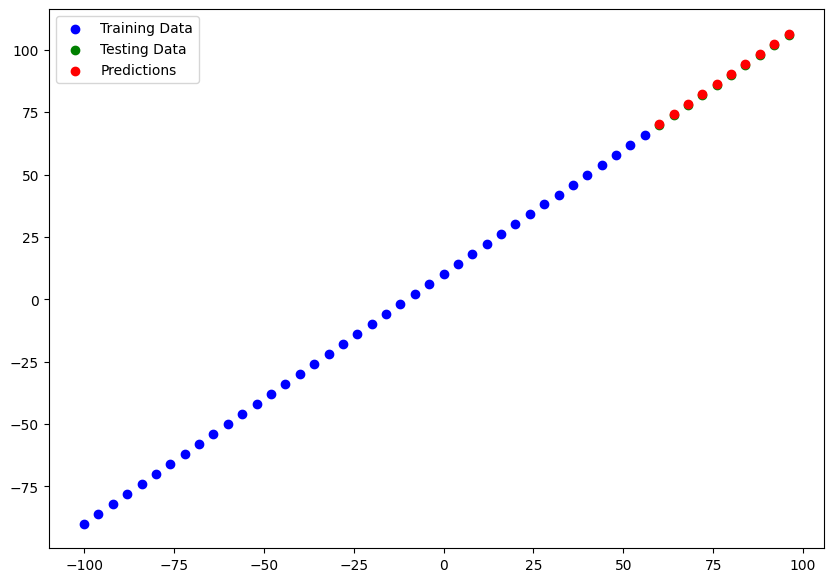

In [204]:
# Make and plot some predictions
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [205]:
mae3 = mae(y_test, tf.squeeze(y_preds_3))
mse3 = mse(y_test, tf.squeeze(y_preds_3))
mae3, mse3

(<tf.Tensor: shape=(), dtype=float32, numpy=0.35473936796188354>,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.12872667610645294>)

## Comparing the results of our experiments

We have run a few expriments, let's compare our results.

🔑 **Note** You want to start with small experiments(small models) and make sure they work and then increase their scale when necessary.

In [206]:
# Let's compare our model's results using pandas DataFrame
import pandas as pd

model_results = [["model_", mae1.numpy(), mse1.numpy()],
                 ["model_2", mae2.numpy(), mse2.numpy()],
                 ["model_3", mae3.numpy(), mse3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_,1.356075,2.653640
1,model_2,0.069308,0.004805
2,model_3,0.354739,0.128727


In [207]:
model_3.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

> 🔑 **Note** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the more things you will figure out which don't work and in turn get closer tofiguring out what does work. Remember the Machine Learning Practioner's motto: "experiment, experiment, experiment".

## Tracking your experiments

One really good habit in Machine Learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you are running lots of experiments.

Luckily there are tools to help us!

📖**Resource:** As you build more models, you will look into using:

* TensorBoard- A component of the TensorFlow Library to help track modelling experiments(we will see this one later).

* Weights and Biases- A tool for tracking all kinds of Machine Learning experiments(Plugs straight into TensorBoard).  

### Saving our Models.

Saving our models allows us to use them outside of Google Colab(or wherever they were trained) such as in web application or a mobile app.

There are two main formats whwere we can save our models too:

1. The SavedModel Format.
2. The HDF5 Model Format.

In [208]:
# Save Model using SavedModel Format
model_3.export("best_model_Saved_Model_format")

Saved artifact at 'best_model_Saved_Model_format'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_53')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132582019922256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132582019919184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132582019909200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132582019920912: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [209]:
# Save the model using HDF5 format
model_3.save("best_model_HDF5_format.h5")

### Loading in a saved model


In [210]:
# # Load in the savedModel format model
# loaded_SavedModel_format = tf.keras.models.load_model("/content/best_model_Saved_Model_format")
# loaded_SavedModel_format.summary()

In [211]:
# Load the model saved in HDF5 format using tf.keras.models.load_model()
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [212]:
model_3.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [213]:
model_3_preds = model_3.predict(X_test)
loaded_h5_model_preds = loaded_h5_model.predict(X_test)
model_3_preds == loaded_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [214]:
mae(y_true=y_test, y_pred=model_3_preds) == mae(y_true=y_test, y_pred=loaded_h5_model_preds)

<tf.Tensor: shape=(10,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])>

In [215]:
model_3_preds, loaded_h5_model_preds

(array([[ 70.27056 ],
        [ 74.28927 ],
        [ 78.307976],
        [ 82.32668 ],
        [ 86.34539 ],
        [ 90.3641  ],
        [ 94.38279 ],
        [ 98.40151 ],
        [102.420204],
        [106.43891 ]], dtype=float32),
 array([[ 70.27056 ],
        [ 74.28927 ],
        [ 78.307976],
        [ 82.32668 ],
        [ 86.34539 ],
        [ 90.3641  ],
        [ 94.38279 ],
        [ 98.40151 ],
        [102.420204],
        [106.43891 ]], dtype=float32))

In [216]:
# Load in a model using the .h5 format
loaded_h5_model1 = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")
loaded_h5_model1.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [217]:
model_3.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [218]:
# Check to see if loaded .h5 model predictions match model 3
model_3_preds = model_3.predict(X_test)
loaded_h5_model1_preds = loaded_h5_model1.predict(X_test)
model_3_preds == loaded_h5_model1_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])